AI MARKETING ANALYTICS PROJECT

Telco Customer Churn Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

In [3]:
# =========================================================
# TASK 1 — DATA CLEANING & CUSTOMER DATA PREPARATION
# =========================================================

# Import Libraries
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn 2.csv")

# Show dataset info
print(df.head())
print(df.info())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Check missing values
print(df.isnull().sum())

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Fill missing values
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

# Feature Engineering

# Average Order Value
df['AverageOrderValue'] = (
    df['TotalCharges'] / (df['tenure'] + 1)
)

# Purchase Frequency
df['PurchaseFrequency'] = (
    df['tenure'] / 12
)

# Customer Lifetime Value
df['CLV'] = (
    df['MonthlyCharges'] * df['tenure']
)

# Days Since Last Purchase
df['DaysSinceLastPurchase'] = (
    (72 - df['tenure']) * 30
)

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

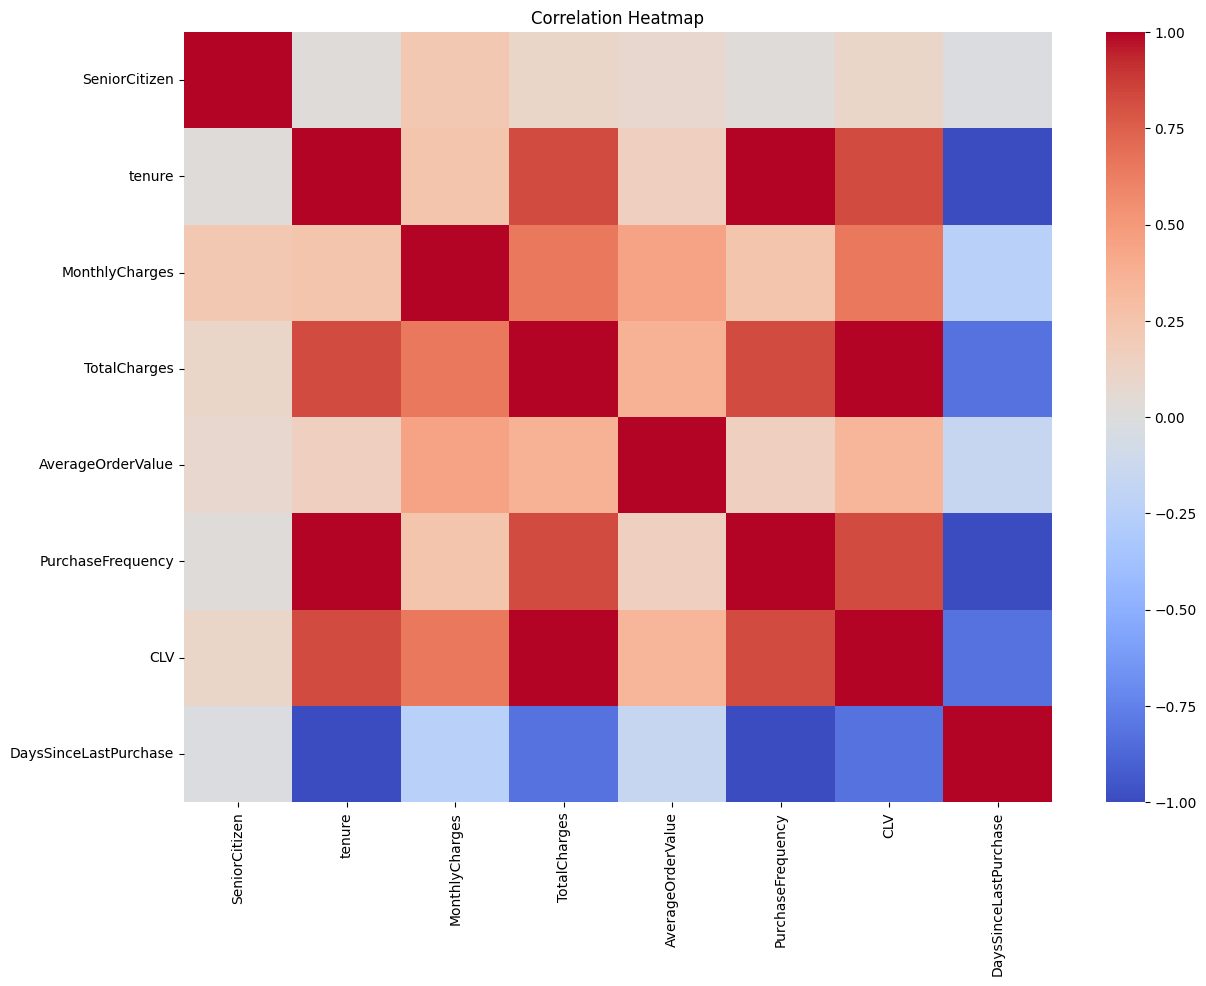

In [5]:
# =========================================================
# TASK 2 — EXPLORATORY DATA ANALYSIS & CUSTOMER INSIGHTS
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Correlation Heatmap
# -------------------------

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


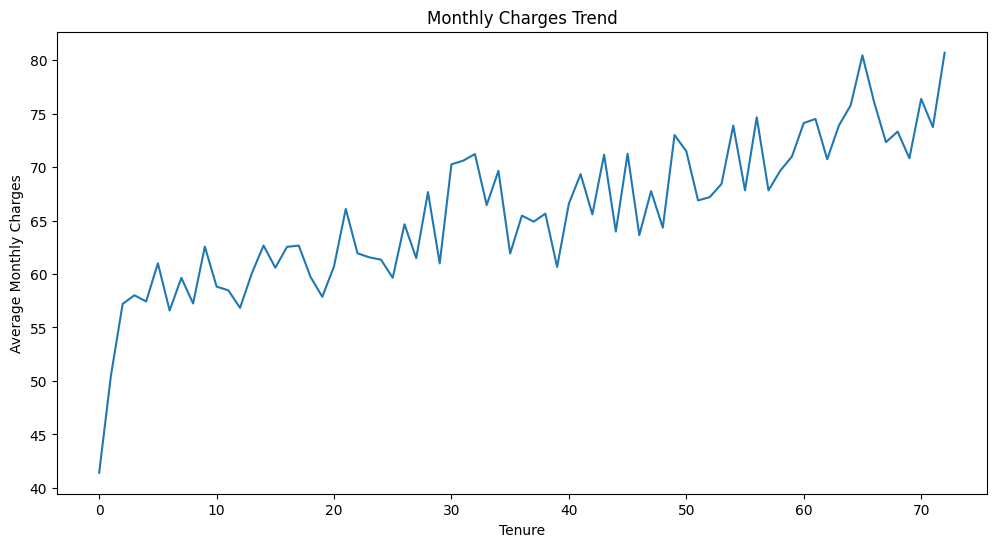

In [6]:
# -------------------------
# Time-Series Trend Chart
# -------------------------

monthly_trend = df.groupby('tenure')[
    'MonthlyCharges'
].mean()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_trend.index,
    monthly_trend.values
)

plt.title("Monthly Charges Trend")

plt.xlabel("Tenure")

plt.ylabel("Average Monthly Charges")

plt.show()


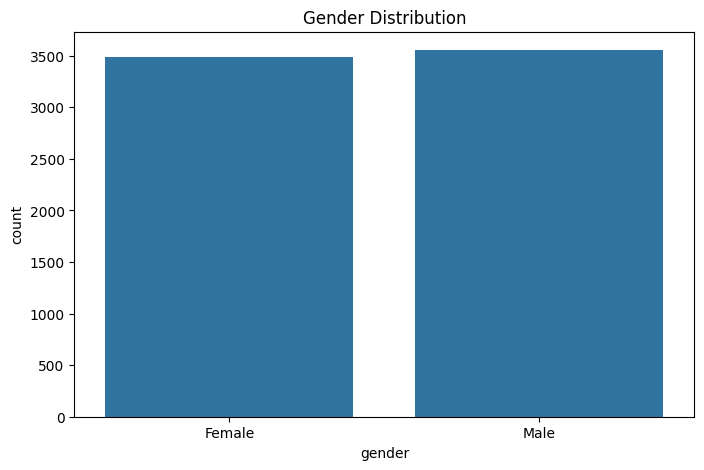

In [7]:
# -------------------------
# Demographic Breakdown
# -------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    x='gender',
    data=df
)

plt.title("Gender Distribution")

plt.show()


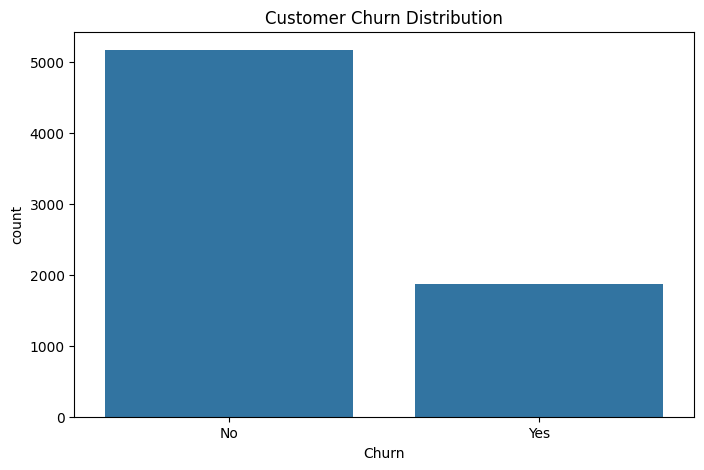

In [8]:
# -------------------------
# Churn Distribution
# -------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()


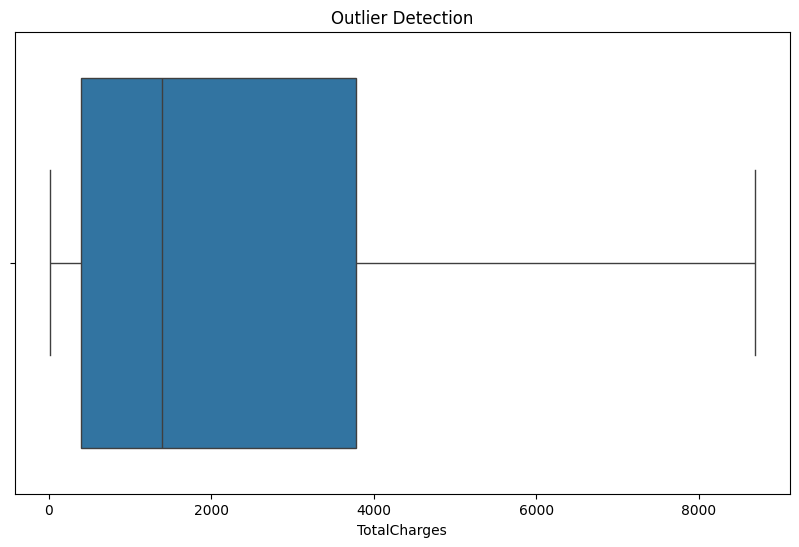

In [9]:
# -------------------------
# Outlier Detection
# -------------------------

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['TotalCharges']
)

plt.title("Outlier Detection")

plt.show()


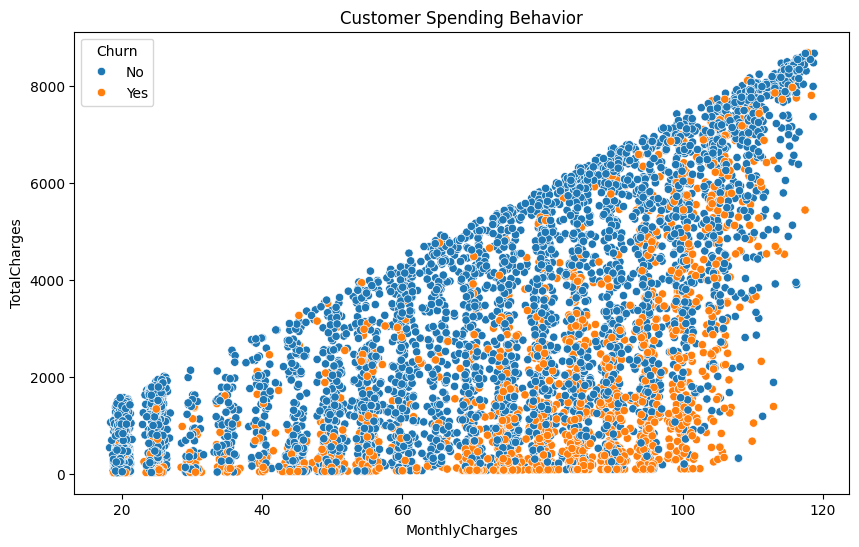

In [10]:
# -------------------------
# Spending Behavior
# -------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Churn',
    data=df
)

plt.title("Customer Spending Behavior")

plt.show()

In [11]:
# =========================================================
# TASK 3 — CUSTOMER SEGMENTATION & TARGETING MODEL
# =========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select Features
cluster_features = df[[
    'MonthlyCharges',
    'TotalCharges',
    'tenure',
    'CLV'
]]

# Standardization
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_features
)

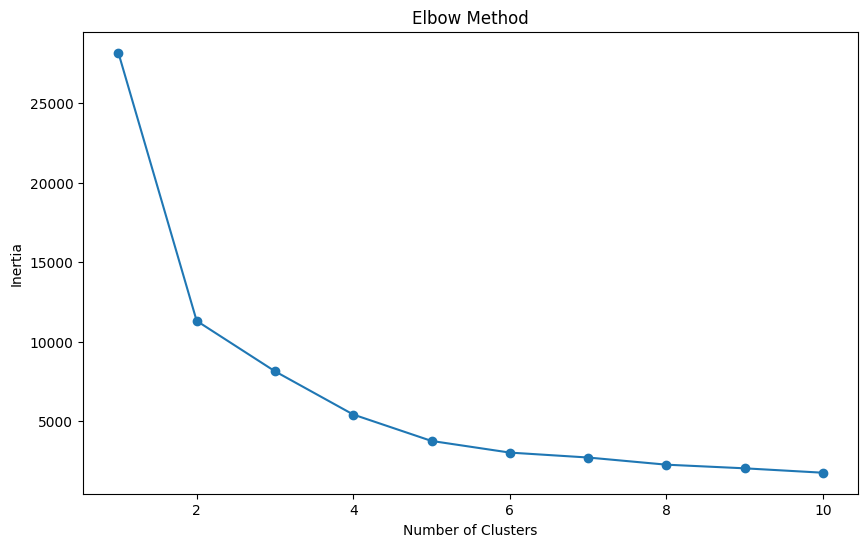

In [12]:
# -------------------------
# Elbow Method
# -------------------------

inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [13]:
# -------------------------
# K-Means Clustering
# -------------------------

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(
    scaled_features
)

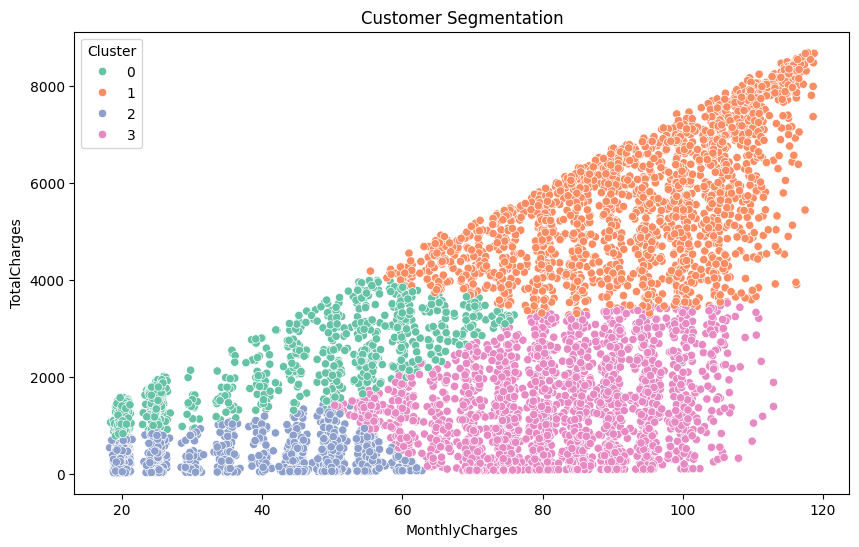

In [14]:
# -------------------------
# Cluster Visualization
# -------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Cluster',
    palette='Set2',
    data=df
)

plt.title("Customer Segmentation")

plt.show()


In [15]:
# -------------------------
# Cluster Summary
# -------------------------

cluster_summary = df.groupby('Cluster')[[
    'MonthlyCharges',
    'TotalCharges',
    'tenure',
    'CLV'
]].mean()

print(cluster_summary)

print("""
Cluster 0 → High-Value Loyalists
Cluster 1 → At-Risk Customers
Cluster 2 → New Customers
Cluster 3 → Bargain Hunters
""")

         MonthlyCharges  TotalCharges     tenure          CLV
Cluster                                                      
0             36.981552   1920.736768  53.564885  1919.851654
1             93.629465   5588.788610  59.810160  5586.173743
2             31.799002    312.506874  10.600685   306.381004
3             81.073003   1253.071408  15.354306  1253.170705

Cluster 0 → High-Value Loyalists
Cluster 1 → At-Risk Customers
Cluster 2 → New Customers
Cluster 3 → Bargain Hunters



In [17]:
# =========================================================
# TASK 4 — PREDICTIVE CUSTOMER BEHAVIOR MODEL
# =========================================================
# Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in cat_cols:

    if col != 'customerID':

        df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop(['customerID', 'Churn'], axis=1)

y = df['Churn']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression Accuracy: 0.8090844570617459


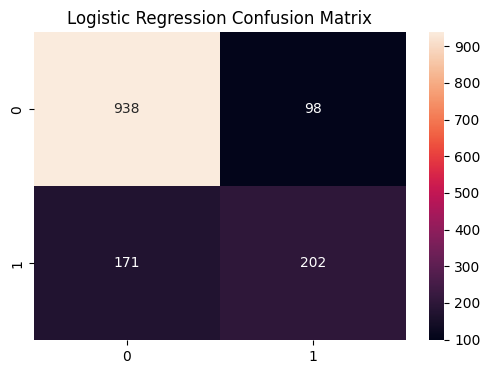

In [18]:
# ======================================================
# MODEL 1 — LOGISTIC REGRESSION
# ======================================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

Random Forest Accuracy: 0.7906316536550745


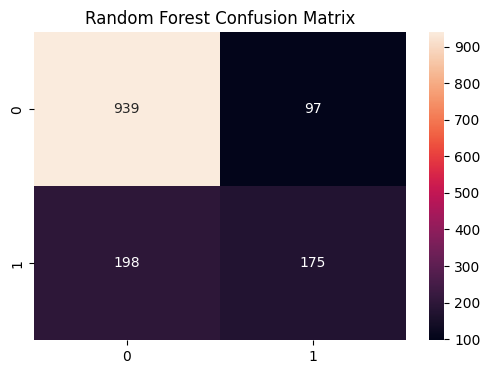

In [19]:
# ======================================================
# MODEL 2 — RANDOM FOREST
# ======================================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")

plt.show()

XGBoost Accuracy: 0.7963094393186657


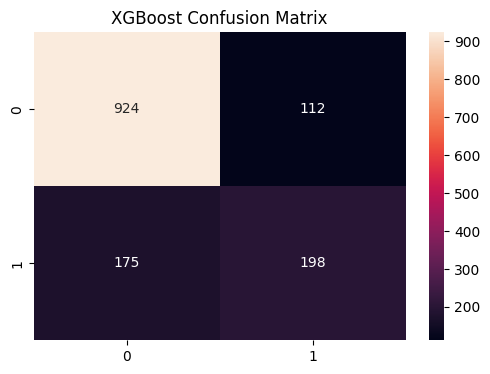

In [20]:
# ======================================================
# MODEL 3 — XGBOOST
# ======================================================

xgb = XGBClassifier(
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("XGBoost Confusion Matrix")

plt.show()

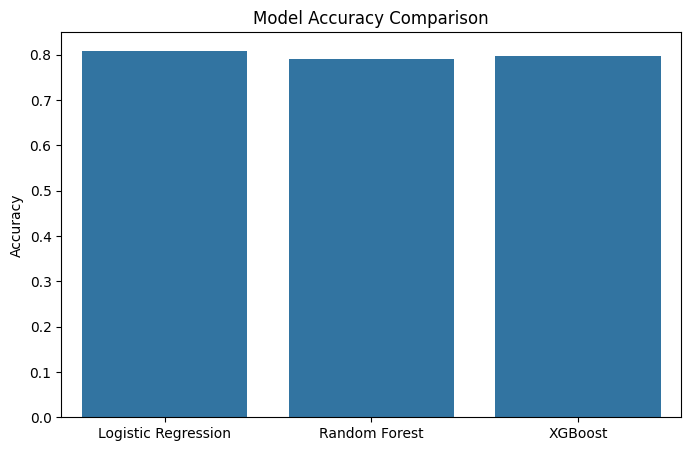

In [21]:
# ======================================================
# MODEL ACCURACY COMPARISON
# ======================================================

models = [
    'Logistic Regression',
    'Random Forest',
    'XGBoost'
]

scores = [
    lr_acc,
    rf_acc,
    xgb_acc
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=scores
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

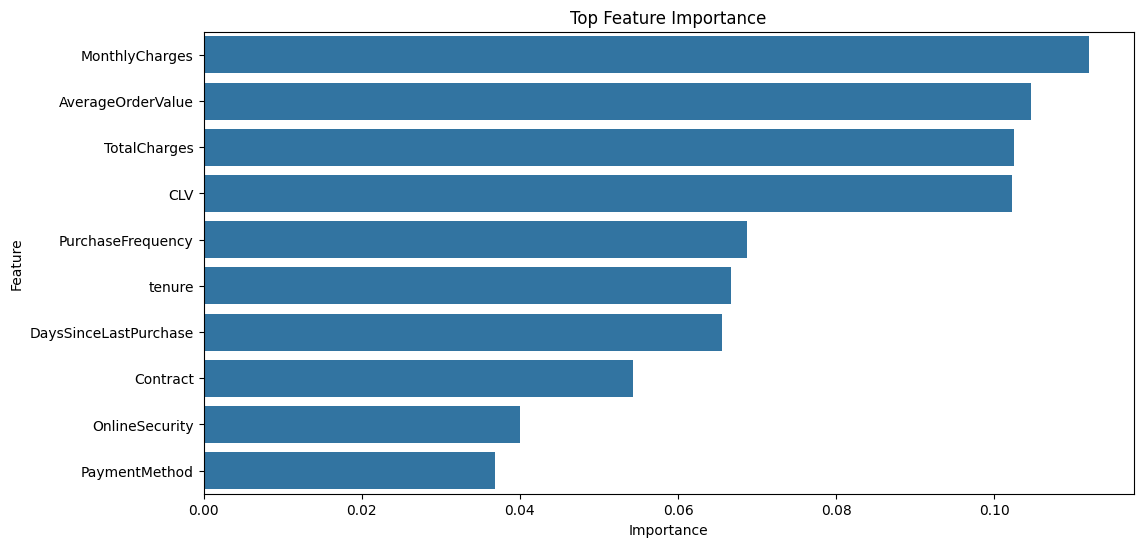

In [22]:
# ======================================================
# FEATURE IMPORTANCE
# ======================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top Feature Importance")

plt.show()

### **Task 5 — AI Recommendation & Personalization System**

In [29]:
df['Profile'] = (
    df['InternetService'].astype(str) + " " +
    df['Contract'].astype(str) + " " +
    df['PaymentMethod'].astype(str)
)

# Vectorization

cv = CountVectorizer(token_pattern=r"\b\w+\b")

matrix = cv.fit_transform(
    df['Profile']
)

# Similarity Matrix

similarity = cosine_similarity(matrix)

# Recommendation Function

def recommend_customer(index):

    similarity_scores = list(
        enumerate(similarity[index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    top_customers = similarity_scores[1:6]

    print("Recommended Similar Customers:")

    for customer in top_customers:

        print(
            "Customer Index:",
            customer[0]
        )

# Example Recommendation

recommend_customer(5)

Recommended Similar Customers:
Customer Index: 5
Customer Index: 8
Customer Index: 14
Customer Index: 17
Customer Index: 19


In [30]:
# =========================================================
# TASK 6 — SENTIMENT ANALYSIS & SOCIAL MEDIA ANALYTICS
# =========================================================
reviews = [
    "Internet speed is amazing and customer support is helpful",
    "Very bad service and expensive monthly charges",
    "Connection is stable and affordable",
    "Terrible billing issues and poor communication",
    "Excellent experience with fiber internet",
    "Support team never responds properly",
    "Fast internet and good contract options",
    "Frequent disconnections make me unhappy",
    "Affordable plans and reliable connection",
    "Worst telecom company I have used"
]
review_df = pd.DataFrame({
    'Review': reviews
})

In [31]:
# Sentiment Function

def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return 'Positive'

    elif polarity < 0:
        return 'Negative'

    else:
        return 'Neutral'

review_df['Sentiment'] = review_df[
    'Review'
].apply(get_sentiment)

print(review_df)


                                              Review Sentiment
0  Internet speed is amazing and customer support...  Positive
1     Very bad service and expensive monthly charges  Negative
2                Connection is stable and affordable   Neutral
3     Terrible billing issues and poor communication  Negative
4           Excellent experience with fiber internet  Positive
5               Support team never responds properly   Neutral
6            Fast internet and good contract options  Positive
7            Frequent disconnections make me unhappy  Negative
8           Affordable plans and reliable connection   Neutral
9                  Worst telecom company I have used  Negative


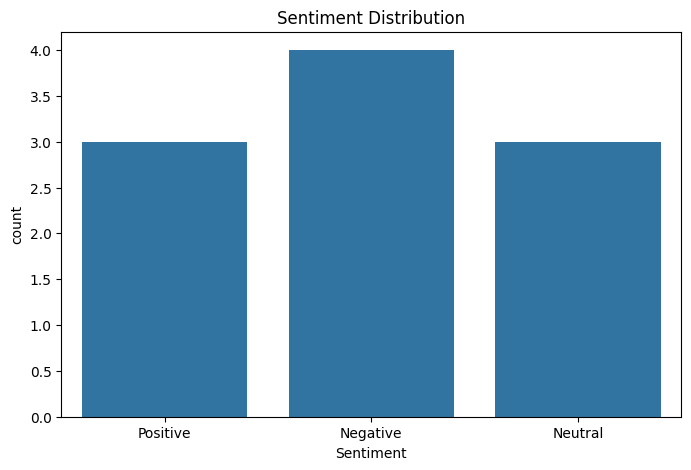

In [32]:
# Sentiment Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=review_df
)

plt.title("Sentiment Distribution")

plt.show()

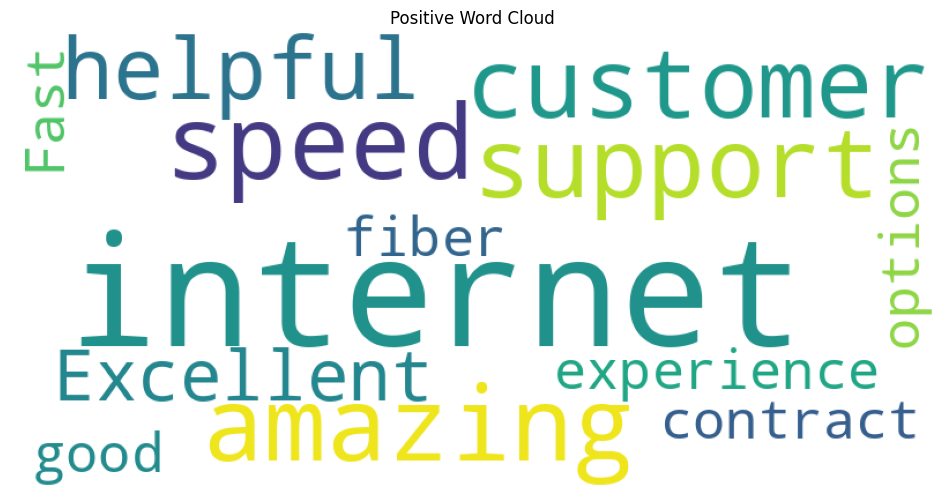

In [33]:
# Positive Word Cloud

positive_text = " ".join(
    review_df[
        review_df['Sentiment'] == 'Positive'
    ]['Review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Word Cloud")

plt.show()


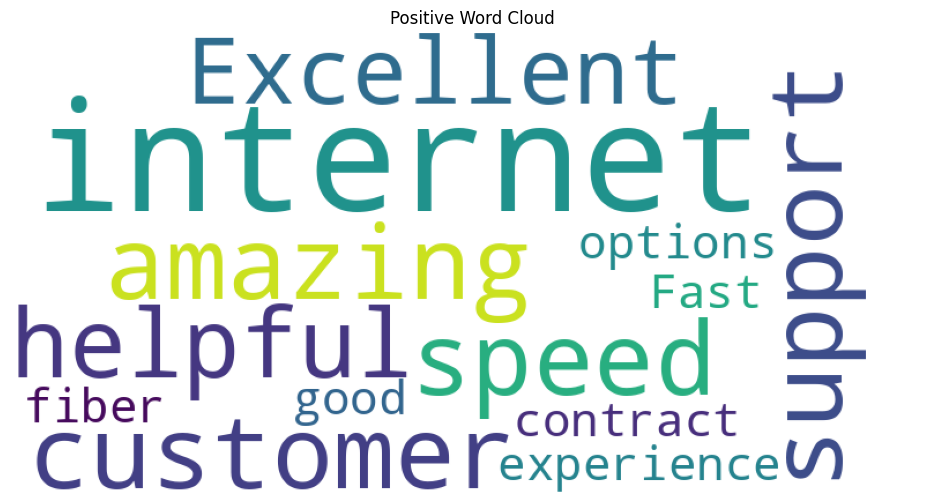

In [34]:
# Positive Word Cloud

positive_text = " ".join(
    review_df[
        review_df['Sentiment'] == 'Positive'
    ]['Review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Word Cloud")

plt.show()


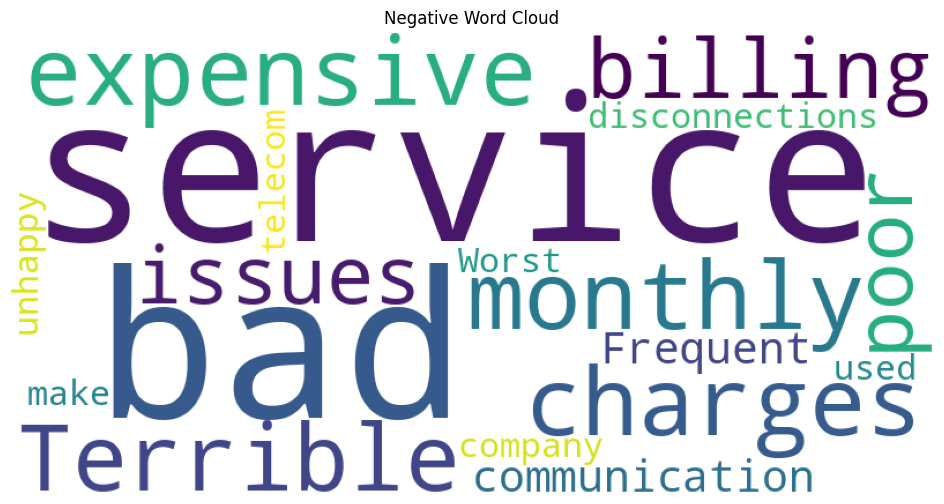

In [35]:
# Negative Word Cloud

negative_text = " ".join(
    review_df[
        review_df['Sentiment'] == 'Negative'
    ]['Review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Negative Word Cloud")

plt.show()


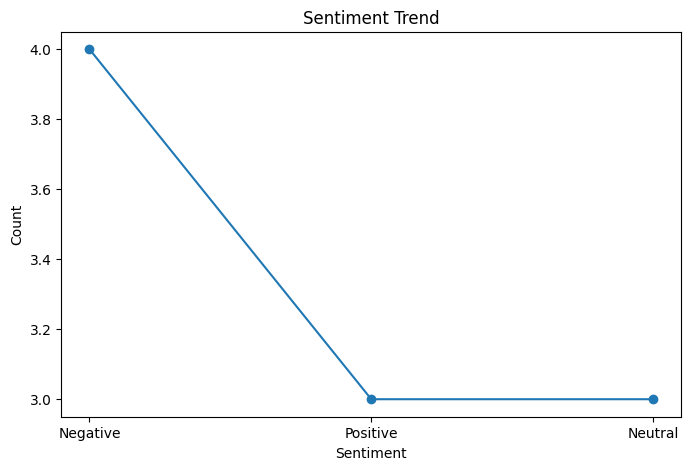

In [36]:
# Sentiment Trend

sentiment_counts = review_df[
    'Sentiment'
].value_counts()

plt.figure(figsize=(8,5))

plt.plot(
    sentiment_counts.index,
    sentiment_counts.values,
    marker='o'
)

plt.title("Sentiment Trend")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()